In [53]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [54]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [55]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Shape: (168, 4)

Missing values:
date              0
food_inflation    0
oni               0
month             0
dtype: int64

Date range:
2012-01-01 00:00:00 to 2025-12-01 00:00:00


In [56]:
TEST_SIZE = 24

train_df = df.iloc[:-TEST_SIZE].copy()
test_df = df.iloc[-TEST_SIZE:].copy()

print("Training:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTesting:")
print(test_df["date"].min(), "→", test_df["date"].max())

Training:
2012-01-01 00:00:00 → 2023-12-01 00:00:00

Testing:
2024-01-01 00:00:00 → 2025-12-01 00:00:00


In [57]:
features = ["food_inflation", "oni"]

feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train_df[features]
)

test_scaled = feature_scaler.transform(
    test_df[features]
)

In [58]:
target_scaler = MinMaxScaler()

target_scaler.fit(
    train_df[["food_inflation"]]
)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[17.89]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-2.65]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[20.54]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['food_inflation']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[0.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,144


In [59]:
def create_sequences(
    features,
    target,
    lookback
):
    X = []
    y = []

    for i in range(
        lookback,
        len(features)
    ):
        X.append(
            features[i - lookback:i]
        )

        y.append(
            target[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

LOOKBACK = 12

In [60]:
train_target_scaled = target_scaler.transform(
    train_df[["food_inflation"]]
).flatten()

In [61]:
X_train_full, y_train_full = create_sequences(
    train_scaled,
    train_target_scaled,
    LOOKBACK
)

print("X shape:", X_train_full.shape)
print("y shape:", y_train_full.shape)

X shape: (132, 12, 2)
y shape: (132,)


In [62]:
VALIDATION_SIZE = 24

X_train = X_train_full[:-VALIDATION_SIZE]
y_train = y_train_full[:-VALIDATION_SIZE]

X_val = X_train_full[-VALIDATION_SIZE:]
y_val = y_train_full[-VALIDATION_SIZE:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 108
Validation samples: 24


In [63]:
model = Sequential([
    LSTM(
        64,
        input_shape=(
            LOOKBACK,
            len(features)
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

In [64]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [65]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [67]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.1190 - val_loss: 0.0626
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0328 - val_loss: 0.0113
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0325 - val_loss: 0.0178
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243 - val_loss: 0.0281
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0229 - val_loss: 0.0194
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0188 - val_loss: 0.0140
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0220 - val_loss: 0.0167
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0173 - val_loss: 0.0178
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0154 - val_loss: 0.0179
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0169 - val_loss: 0.0169
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0164 - val_loss: 0.0160
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0156 - val_lo

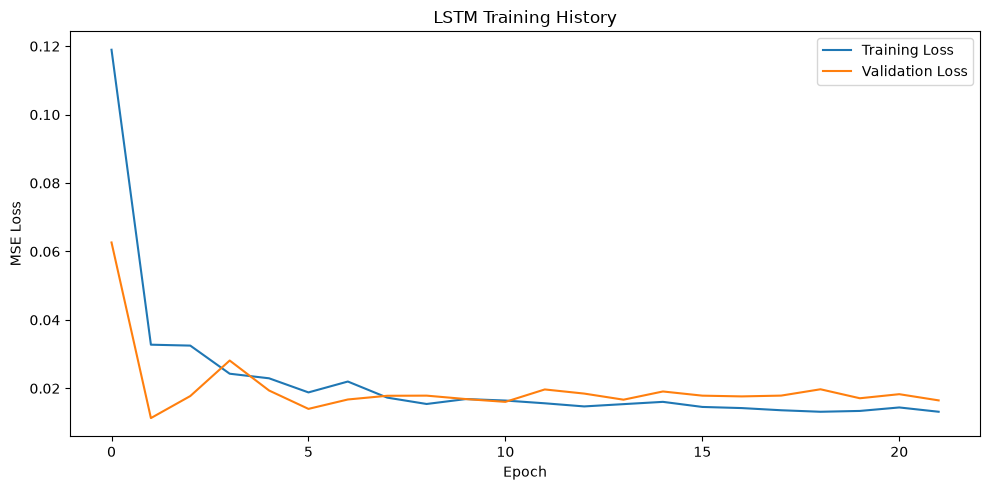

In [68]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()

plt.tight_layout()
plt.show()

In [69]:
combined = pd.concat(
    [
        train_df.tail(LOOKBACK),
        test_df
    ],
    ignore_index=True
)

combined_scaled = feature_scaler.transform(
    combined[features]
)

In [70]:
X_test, _ = create_sequences(
    combined_scaled,
    np.zeros(len(combined_scaled)),
    LOOKBACK
)

In [71]:
X_test = X_test[:len(test_df)]
X_test.shape

(24, 12, 2)

#### Predict

In [72]:
pred_scaled = model.predict(
    X_test,
    verbose=0
)

In [73]:
predicted_food_inflation = (
    target_scaler.inverse_transform(
        pred_scaled
    )
    .flatten()
)

In [74]:
predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": (
        test_df["food_inflation"].values
    ),
    "predicted_food_inflation": (
        predicted_food_inflation
    )
})

display(predictions.head())

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.434288
1,2024-02-01,8.66,9.819040
2,2024-03-01,8.52,10.174467
3,2024-04-01,8.70,10.434925
4,2024-05-01,8.69,10.623059


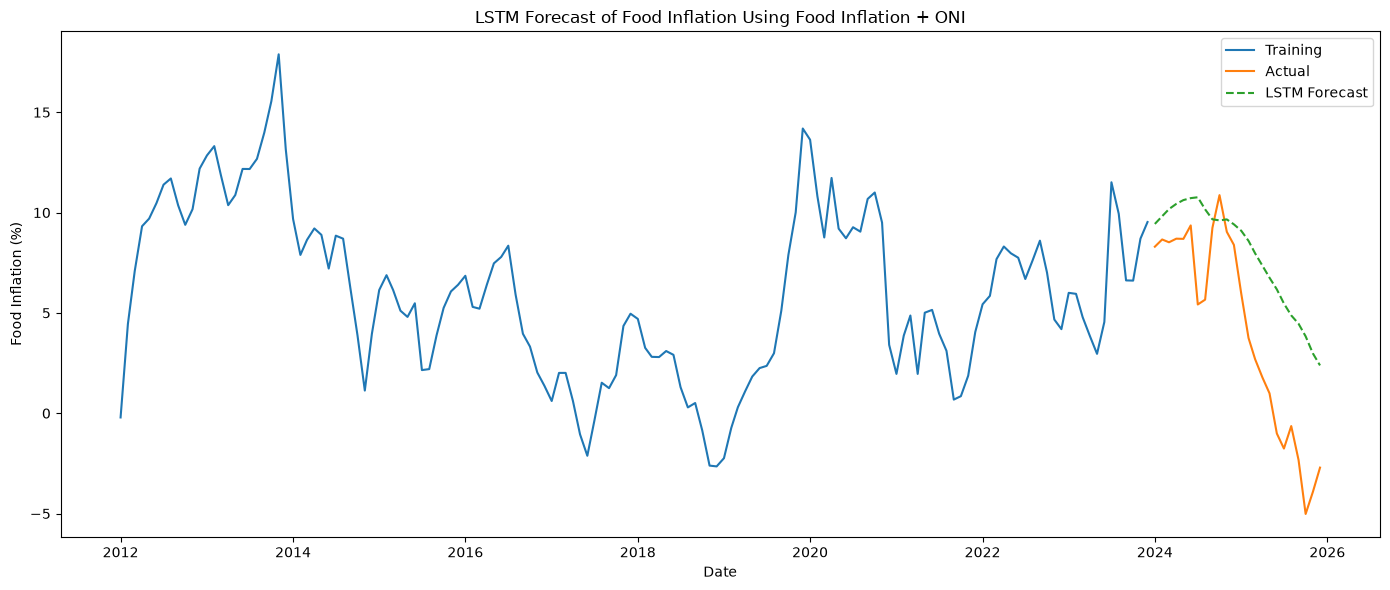

In [75]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df["date"],
    train_df["food_inflation"],
    label="Training"
)

plt.plot(
    test_df["date"],
    test_df["food_inflation"],
    label="Actual"
)

plt.plot(
    predictions["date"],
    predictions["predicted_food_inflation"],
    linestyle="--",
    label="LSTM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("LSTM Forecast of Food Inflation Using Food Inflation + ONI")
plt.legend()

plt.tight_layout()
plt.show()

### <mark>**LSTM baseline**</mark>

In [76]:
features_baseline = ["food_inflation"]

baseline_scaler = MinMaxScaler()

train_baseline_scaled = baseline_scaler.fit_transform(
    train_df[features_baseline]
)

test_baseline_scaled = baseline_scaler.transform(
    test_df[features_baseline]
)

In [77]:
baseline_target_scaler = MinMaxScaler()

baseline_target_scaler.fit(
    train_df[["food_inflation"]]
)

train_baseline_target_scaled = baseline_target_scaler.transform(
    train_df[["food_inflation"]]
).flatten()

In [78]:
X_baseline_full, y_baseline_full = create_sequences(
    train_baseline_scaled,
    train_baseline_target_scaled,
    LOOKBACK
)

print("X shape:", X_baseline_full.shape)
print("y shape:", y_baseline_full.shape)

X shape: (132, 12, 1)
y shape: (132,)


In [79]:
X_baseline_train = X_baseline_full[:-VALIDATION_SIZE]
y_baseline_train = y_baseline_full[:-VALIDATION_SIZE]

X_baseline_val = X_baseline_full[-VALIDATION_SIZE:]
y_baseline_val = y_baseline_full[-VALIDATION_SIZE:]

print("Training samples:", len(X_baseline_train))
print("Validation samples:", len(X_baseline_val))

Training samples: 108
Validation samples: 24


In [80]:
baseline_model = Sequential([
    LSTM(
        64,
        input_shape=(
            LOOKBACK,
            len(features_baseline)
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])
baseline_model.compile(
    optimizer="adam",
    loss="mse"
)

baseline_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [82]:
baseline_history = baseline_model.fit(
    X_baseline_train,
    y_baseline_train,
    validation_data=(
        X_baseline_val,
        y_baseline_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[baseline_early_stopping],
    verbose=1
)

Epoch 1/300


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.1467 - val_loss: 0.0699
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0358 - val_loss: 0.0146
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0365 - val_loss: 0.0137
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0248 - val_loss: 0.0243
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0234 - val_loss: 0.0184
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0207 - val_loss: 0.0133
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0216 - val_loss: 0.0138
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0194 - val_loss: 0.0163
Epoch 9/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0184 - val_loss: 0.0145
Epoch 10/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0163 - val_loss: 0.0135
Epoch 11/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0175 - val_loss: 0.0134
Epoch 12/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0174 - val_loss: 0.0147
E

In [83]:
print("Best validation loss:",
      min(baseline_history.history["val_loss"]))

print("Best epoch:",
      np.argmin(baseline_history.history["val_loss"]) + 1)

Best validation loss: 0.00881157722324133
Best epoch: 157


In [84]:
# Combine the last 12 training months with the test data
baseline_test_input = pd.concat(
    [
        train_df[features_baseline].tail(LOOKBACK),
        test_df[features_baseline]
    ],
    ignore_index=True
)

# Scale using the scaler fitted on training data
baseline_test_scaled = baseline_scaler.transform(
    baseline_test_input
)

print("Test input shape:", baseline_test_scaled.shape)

Test input shape: (36, 1)


In [85]:
X_baseline_test = []

for i in range(
    LOOKBACK,
    len(baseline_test_scaled)
):
    X_baseline_test.append(
        baseline_test_scaled[i - LOOKBACK:i]
    )

X_baseline_test = np.array(X_baseline_test)

print("X_test shape:", X_baseline_test.shape)

X_test shape: (24, 12, 1)


In [86]:
baseline_pred_scaled = baseline_model.predict(
    X_baseline_test
)

print("Prediction shape:", baseline_pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Prediction shape: (24, 1)


In [87]:
baseline_predicted_food_inflation = (
    baseline_target_scaler.inverse_transform(
        baseline_pred_scaled
    ).flatten()
)

print(
    baseline_predicted_food_inflation[:5]
)

[9.009978  7.7706375 8.310725  8.15608   8.28494  ]


In [88]:
baseline_predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": (
        test_df["food_inflation"].values
    ),
    "predicted_food_inflation": (
        baseline_predicted_food_inflation
    )
})

display(baseline_predictions.head())

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.009978
1,2024-02-01,8.66,7.770638
2,2024-03-01,8.52,8.310725
3,2024-04-01,8.70,8.156080
4,2024-05-01,8.69,8.284940


In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = baseline_predictions["actual_food_inflation"]
predicted = baseline_predictions["predicted_food_inflation"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

smape = np.mean(
    2 * np.abs(actual - predicted) /
    (np.abs(actual) + np.abs(predicted))
) * 100

print("Baseline LSTM MAE:", mae)
print("Baseline LSTM RMSE:", rmse)
print("Baseline LSTM sMAPE:", smape)

Baseline LSTM MAE: 1.3334747018913429
Baseline LSTM RMSE: 1.6459704247752707
Baseline LSTM sMAPE: 43.8899977999094


In [90]:
train_actual = train_df["food_inflation"].values

naive_errors = np.abs(
    train_actual[1:] - train_actual[:-1]
)

mae_naive = np.mean(naive_errors)

mase = mae / mae_naive

print("Baseline LSTM MASE:", mase)

Baseline LSTM MASE: 0.9909871453883078


In [91]:
baseline_predictions.to_csv(
    "../data/processed/lstm_baseline_predictions.csv",
    index=False
)

In [105]:
# Final LSTM + ONI: determine best epoch for LOOKBACK = 18

FINAL_LOOKBACK = 18

X_18_full, y_18_full = create_sequences(
    train_scaled,
    train_target_scaled,
    FINAL_LOOKBACK
)

X_18_train = X_18_full[:-VALIDATION_SIZE]
y_18_train = y_18_full[:-VALIDATION_SIZE]

X_18_val = X_18_full[-VALIDATION_SIZE:]
y_18_val = y_18_full[-VALIDATION_SIZE:]

final_val_model = Sequential([
    LSTM(
        64,
        input_shape=(
            FINAL_LOOKBACK,
            len(features)
        )
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

final_val_model.compile(
    optimizer="adam",
    loss="mse"
)

final_val_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

final_val_history = final_val_model.fit(
    X_18_train,
    y_18_train,
    validation_data=(
        X_18_val,
        y_18_val
    ),
    epochs=300,
    batch_size=16,
    callbacks=[final_val_early_stopping],
    verbose=0
)

best_epoch_18 = (
    np.argmin(final_val_history.history["val_loss"]) + 1
)

best_val_loss_18 = min(
    final_val_history.history["val_loss"]
)

print("Selected LOOKBACK:", FINAL_LOOKBACK)
print("Best validation loss:", best_val_loss_18)
print("Best epoch:", best_epoch_18)

Selected LOOKBACK: 18
Best validation loss: 0.010790862143039703
Best epoch: 71


In [106]:
# Final LSTM + ONI model with LOOKBACK = 18

X_final_18, y_final_18 = create_sequences(
    train_scaled,
    train_target_scaled,
    FINAL_LOOKBACK
)

final_lstm_oni_model = Sequential([
    LSTM(
        64,
        input_shape=(
            FINAL_LOOKBACK,
            len(features)
        )
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

final_lstm_oni_model.compile(
    optimizer="adam",
    loss="mse"
)

final_lstm_oni_model.fit(
    X_final_18,
    y_final_18,
    epochs=best_epoch_18,
    batch_size=16,
    verbose=1
)

print("Final LSTM + ONI training completed.")
print("LOOKBACK:", FINAL_LOOKBACK)
print("Epochs:", best_epoch_18)
print("Training samples:", len(X_final_18))

Epoch 1/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1122
Epoch 2/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0332
Epoch 3/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0293 
Epoch 4/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0243
Epoch 5/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0204
Epoch 6/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0208
Epoch 7/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0184
Epoch 8/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0188
Epoch 9/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0173
Epoch 10/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0176
Epoch 11/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0164
Epoch 12/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0146
Epoch 13/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0123
Epoch 14/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0132
Epoch 15/71
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0157
Epoch 16/71
8/8 ━━━━━━━━━━━━━━━━━

In [107]:
# ============================================
# FINAL LSTM + ONI: TEST PREDICTION & EVALUATION
# ============================================

# Combine the last LOOKBACK training observations
# with the complete test period so every test month
# has the required historical context.
combined_features = pd.concat(
    [
        train_df[features].tail(FINAL_LOOKBACK),
        test_df[features]
    ],
    ignore_index=True
)

# Scale using the scaler fitted ONLY on training data
combined_features_scaled = feature_scaler.transform(combined_features)

# Create test input sequences
X_test_18 = []

for i in range(FINAL_LOOKBACK, len(combined_features_scaled)):
    X_test_18.append(
        combined_features_scaled[i-FINAL_LOOKBACK:i]
    )

X_test_18 = np.array(X_test_18)

# Predict scaled food inflation
predicted_scaled_18 = final_lstm_oni_model.predict(
    X_test_18,
    verbose=0
)

# Convert predictions back to original scale
predicted_food_18 = target_scaler.inverse_transform(
    predicted_scaled_18
).flatten()

# Actual test values
actual_food_18 = test_df["food_inflation"].values

# --------------------------------------------
# Metrics
# --------------------------------------------

mae_lstm_18 = mean_absolute_error(
    actual_food_18,
    predicted_food_18
)

rmse_lstm_18 = np.sqrt(
    np.mean((actual_food_18 - predicted_food_18) ** 2)
)

smape_lstm_18 = (
    100
    * np.mean(
        2 * np.abs(actual_food_18 - predicted_food_18)
        / (
            np.abs(actual_food_18)
            + np.abs(predicted_food_18)
            + 1e-8
        )
    )
)

# MASE using training-set naive forecast errors
train_actual = train_df["food_inflation"].values

naive_errors = np.abs(
    train_actual[1:] - train_actual[:-1]
)

mae_naive = np.mean(naive_errors)

mase_lstm_18 = mae_lstm_18 / mae_naive

# --------------------------------------------
# Results
# --------------------------------------------

print("FINAL LSTM + ONI RESULTS")
print("-" * 40)
print("LOOKBACK:", FINAL_LOOKBACK)
print("MAE:", mae_lstm_18)
print("RMSE:", rmse_lstm_18)
print("sMAPE:", smape_lstm_18)
print("MASE:", mase_lstm_18)

FINAL LSTM + ONI RESULTS
----------------------------------------
LOOKBACK: 18
MAE: 1.524525444833562
RMSE: 1.9421880589664577
sMAPE: 49.63711875876435
MASE: 1.1329687143705234


In [108]:
# ============================================
# SAVE FINAL LSTM + ONI PREDICTIONS
# ============================================

lstm_predictions = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_food_inflation": actual_food_18,
    "predicted_food_inflation": predicted_food_18
})

print("Shape:", lstm_predictions.shape)
display(lstm_predictions.head())
display(lstm_predictions.tail())

lstm_predictions.to_csv(
    "../data/processed/lstm_predictions.csv",
    index=False
)

print("\nSaved:")
print("../data/processed/lstm_predictions.csv")

Shape: (24, 3)


,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.891513
1,2024-02-01,8.66,9.495182
2,2024-03-01,8.52,9.617790
3,2024-04-01,8.70,9.496943
4,2024-05-01,8.69,9.422193


,date,actual_food_inflation,predicted_food_inflation
19,2025-08-01,-0.64,-0.732881
20,2025-09-01,-2.33,-0.298015
21,2025-10-01,-5.02,-0.895572
22,2025-11-01,-3.91,-2.490084
23,2025-12-01,-2.71,-2.588135



Saved:
../data/processed/lstm_predictions.csv


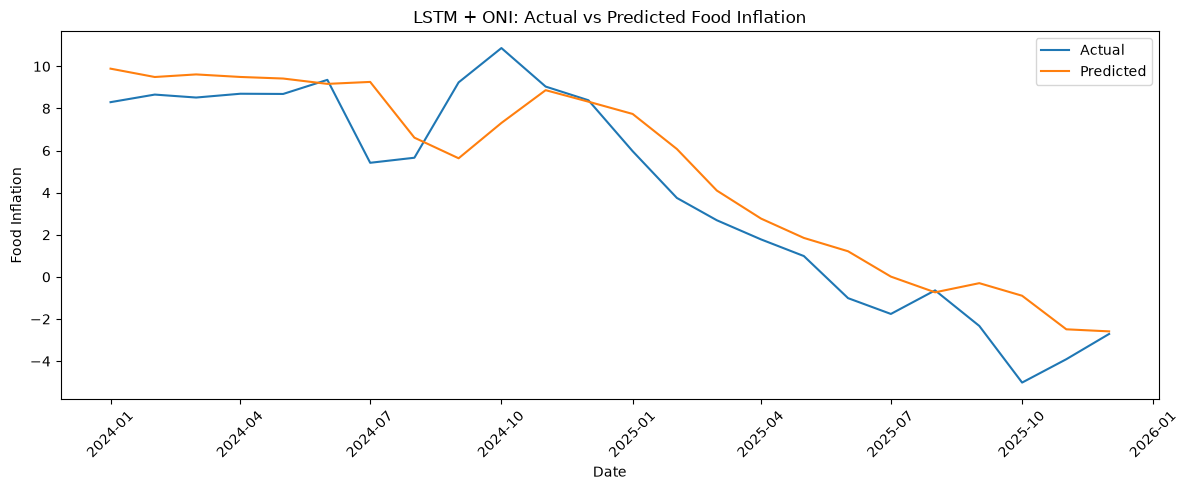

In [109]:
# ============================================
# LSTM + ONI (LOOKBACK=18)
# ACTUAL vs PREDICTED
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    lstm_predictions["date"],
    lstm_predictions["actual_food_inflation"],
    label="Actual"
)

plt.plot(
    lstm_predictions["date"],
    lstm_predictions["predicted_food_inflation"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation")
plt.title("LSTM + ONI: Actual vs Predicted Food Inflation")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

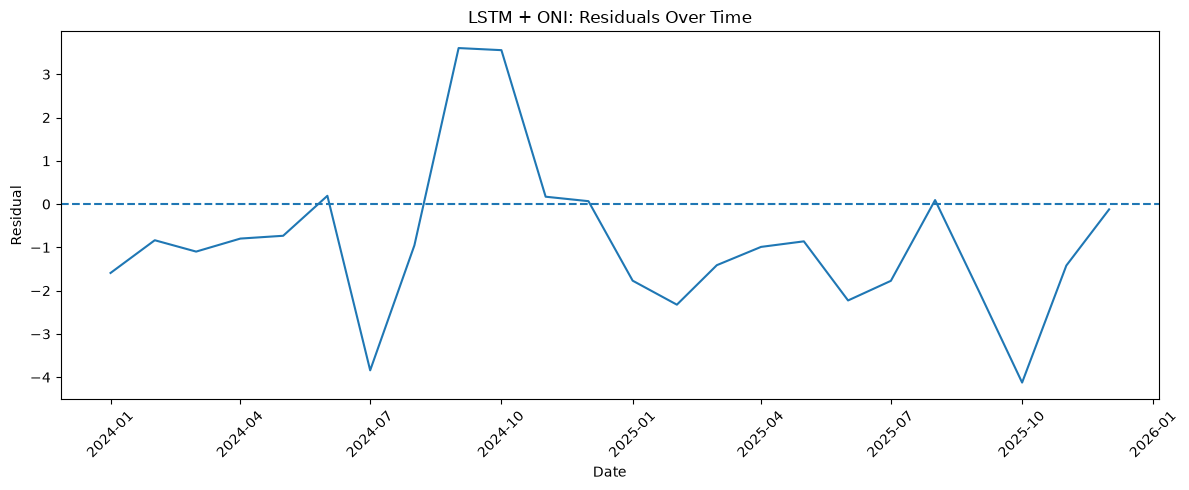

In [110]:
# ============================================
# LSTM + ONI RESIDUALS
# ============================================

lstm_predictions["residual"] = (
    lstm_predictions["actual_food_inflation"]
    - lstm_predictions["predicted_food_inflation"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    lstm_predictions["date"],
    lstm_predictions["residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("LSTM + ONI: Residuals Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

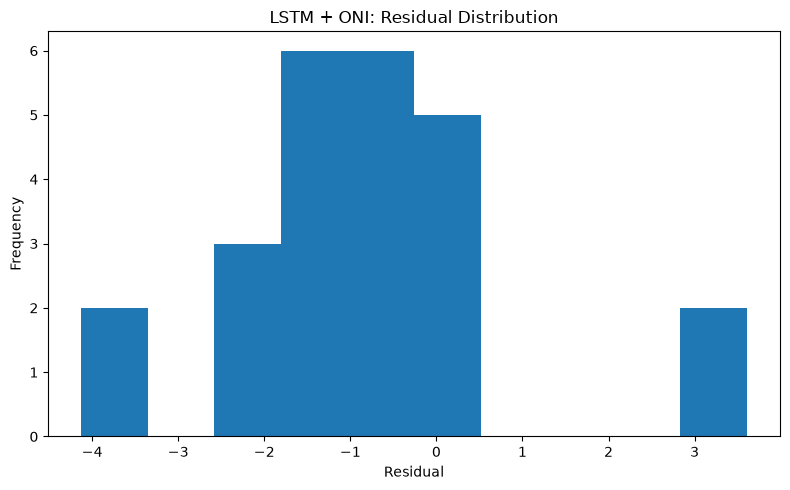

In [111]:
# ============================================
# RESIDUAL DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    lstm_predictions["residual"],
    bins=10
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("LSTM + ONI: Residual Distribution")
plt.tight_layout()
plt.show()

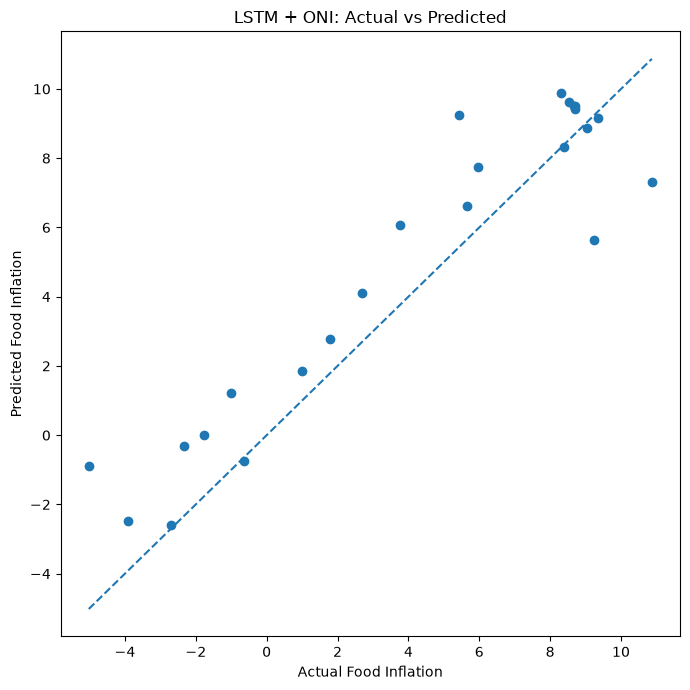

In [112]:
# ============================================
# ACTUAL vs PREDICTED SCATTER
# ============================================

plt.figure(figsize=(7, 7))

plt.scatter(
    lstm_predictions["actual_food_inflation"],
    lstm_predictions["predicted_food_inflation"]
)

min_val = min(
    lstm_predictions["actual_food_inflation"].min(),
    lstm_predictions["predicted_food_inflation"].min()
)

max_val = max(
    lstm_predictions["actual_food_inflation"].max(),
    lstm_predictions["predicted_food_inflation"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Food Inflation")
plt.ylabel("Predicted Food Inflation")
plt.title("LSTM + ONI: Actual vs Predicted")
plt.tight_layout()
plt.show()

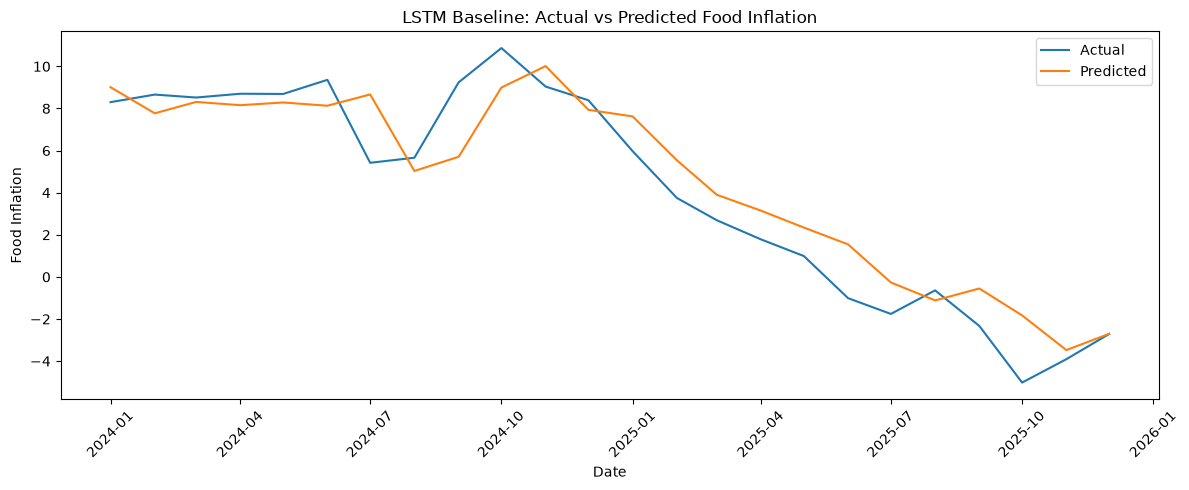

In [113]:
# ============================================
# LSTM BASELINE (LOOKBACK=12)
# ACTUAL vs PREDICTED
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    baseline_predictions["date"],
    baseline_predictions["actual_food_inflation"],
    label="Actual"
)

plt.plot(
    baseline_predictions["date"],
    baseline_predictions["predicted_food_inflation"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation")
plt.title("LSTM Baseline: Actual vs Predicted Food Inflation")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

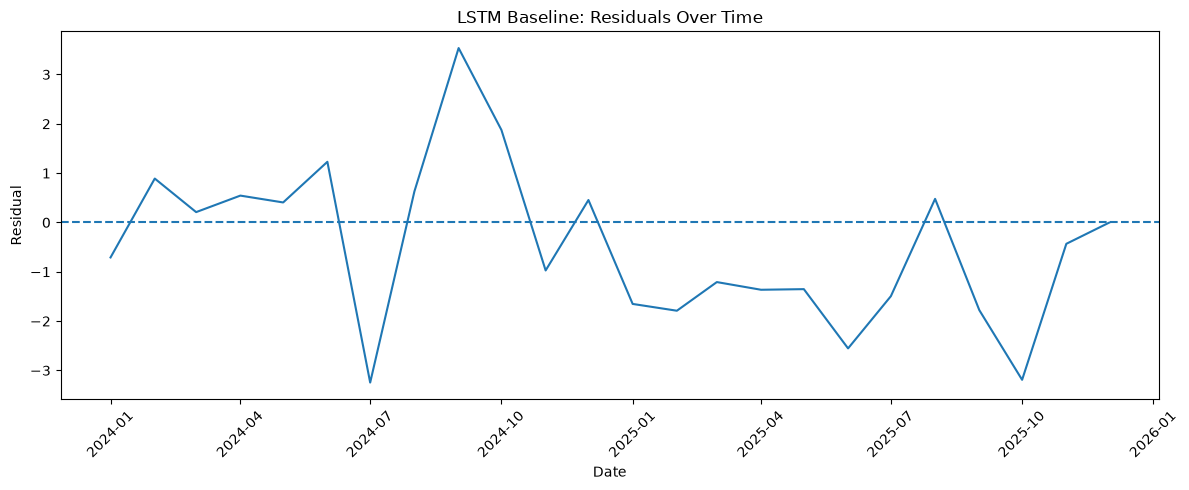

In [114]:
# ============================================
# LSTM BASELINE RESIDUALS
# ============================================

baseline_predictions["residual"] = (
    baseline_predictions["actual_food_inflation"]
    - baseline_predictions["predicted_food_inflation"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    baseline_predictions["date"],
    baseline_predictions["residual"]
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("LSTM Baseline: Residuals Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

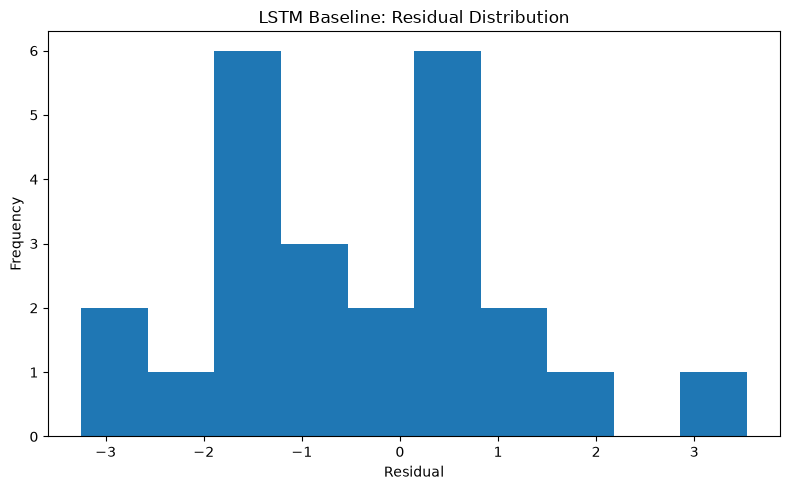

In [115]:
# ============================================
# LSTM BASELINE RESIDUAL DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    baseline_predictions["residual"],
    bins=10
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("LSTM Baseline: Residual Distribution")
plt.tight_layout()
plt.show()

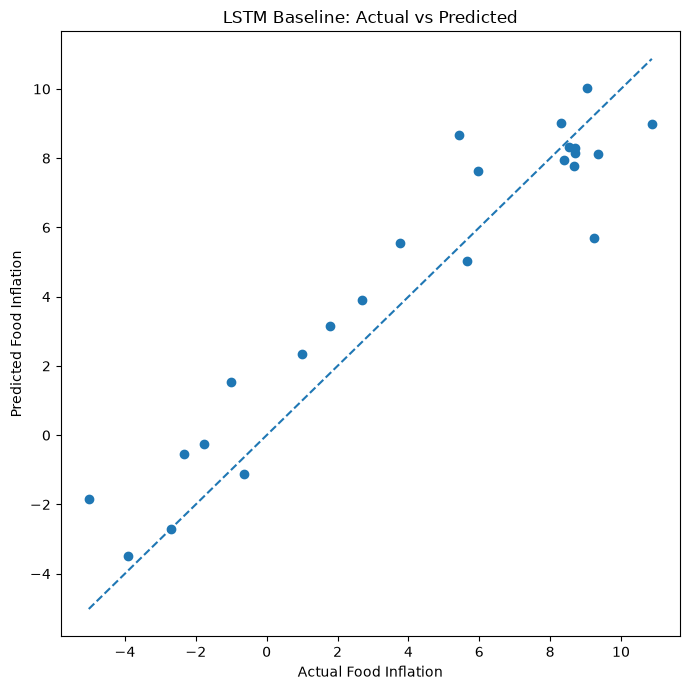

In [116]:
# ============================================
# LSTM BASELINE ACTUAL vs PREDICTED SCATTER
# ============================================

plt.figure(figsize=(7, 7))

plt.scatter(
    baseline_predictions["actual_food_inflation"],
    baseline_predictions["predicted_food_inflation"]
)

min_val = min(
    baseline_predictions["actual_food_inflation"].min(),
    baseline_predictions["predicted_food_inflation"].min()
)

max_val = max(
    baseline_predictions["actual_food_inflation"].max(),
    baseline_predictions["predicted_food_inflation"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Food Inflation")
plt.ylabel("Predicted Food Inflation")
plt.title("LSTM Baseline: Actual vs Predicted")
plt.tight_layout()
plt.show()

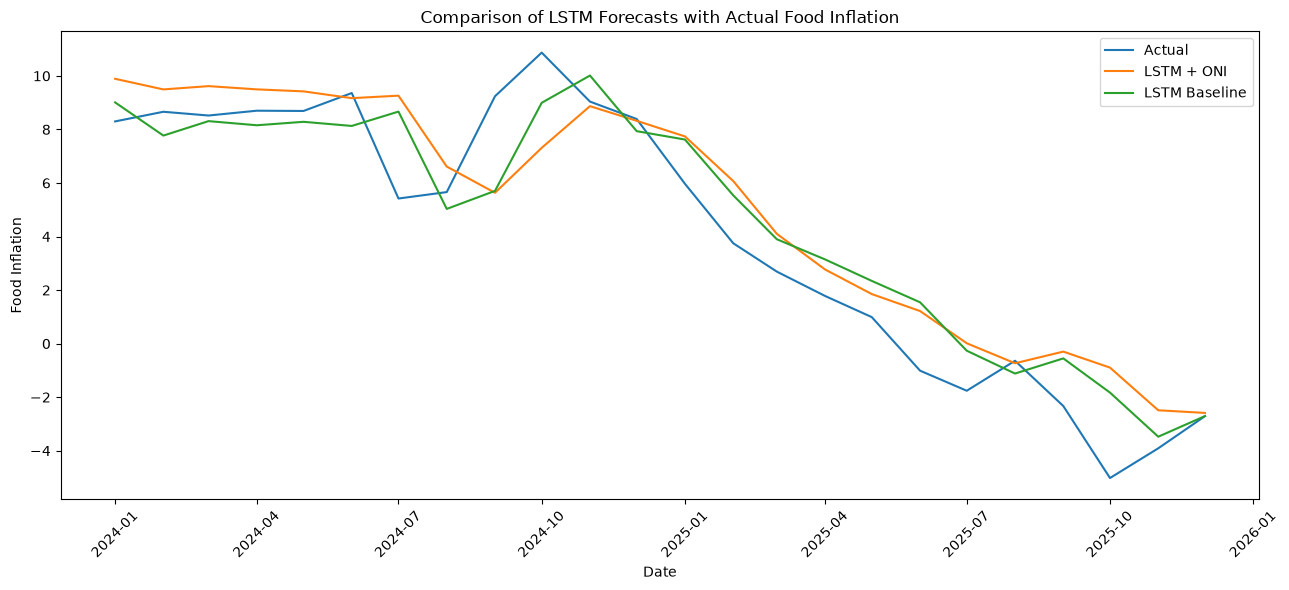

In [117]:
# ============================================
# FINAL LSTM COMPARISON
# ACTUAL vs LSTM + ONI vs LSTM BASELINE
# ============================================

plt.figure(figsize=(13, 6))

# Actual values
plt.plot(
    lstm_predictions["date"],
    lstm_predictions["actual_food_inflation"],
    label="Actual"
)

# LSTM + ONI
plt.plot(
    lstm_predictions["date"],
    lstm_predictions["predicted_food_inflation"],
    label="LSTM + ONI"
)

# LSTM Baseline
plt.plot(
    baseline_predictions["date"],
    baseline_predictions["predicted_food_inflation"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation")
plt.title("Comparison of LSTM Forecasts with Actual Food Inflation")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()